In [3]:
pip install ucimlrepo scikit-learn seaborn matplotlib pandas

In [4]:
from ucimlrepo import fetch_ucirepo


DatosBaseVinos = fetch_ucirepo(id=186)
X = DatosBaseVinos.data.features
y = DatosBaseVinos.data.targets
print(DatosBaseVinos.metadata)
print(DatosBaseVinos.variables)

{'uci_id': 186, 'name': 'Wine Quality', 'repository_url': 'https://archive.ics.uci.edu/dataset/186/wine+quality', 'data_url': 'https://archive.ics.uci.edu/static/public/186/data.csv', 'abstract': 'Two datasets are included, related to red and white vinho verde wine samples, from the north of Portugal. The goal is to model wine quality based on physicochemical tests (see [Cortez et al., 2009], http://www3.dsi.uminho.pt/pcortez/wine/).', 'area': 'Business', 'tasks': ['Classification', 'Regression'], 'characteristics': ['Multivariate'], 'num_instances': 4898, 'num_features': 11, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['quality'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2009, 'last_updated': 'Wed Nov 15 2023', 'dataset_doi': '10.24432/C56S3T', 'creators': ['Paulo Cortez', 'A. Cerdeira', 'F. Almeida', 'T. Matos', 'J. Reis'], 'intro_paper': {'ID': 252, 'type': 'NATIVE', 'title': 'Modeling wine preferences

📊 Reporte de clasificación - Multiclase:

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         7
           4       0.30      0.29      0.29        45
           5       0.68      0.69      0.68       419
           6       0.67      0.66      0.67       564
           7       0.55      0.60      0.58       220
           8       0.48      0.31      0.38        45
           9       0.00      0.00      0.00         0

    accuracy                           0.63      1300
   macro avg       0.38      0.37      0.37      1300
weighted avg       0.63      0.63      0.63      1300



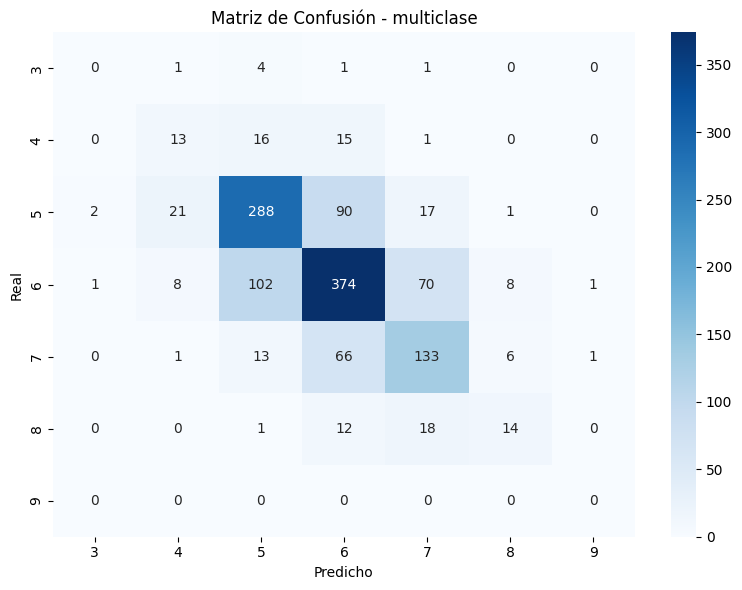

In [10]:
from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sb
import pandas as pd

DatosBaseVinos = fetch_ucirepo(id=186)
X = DatosBaseVinos.data.features
y = DatosBaseVinos.data.targets['quality']
DatosEscalados = StandardScaler()
X_scaled = DatosEscalados.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=50)
mlp = MLPClassifier(hidden_layer_sizes=(100, 100), activation='relu', solver='adam', max_iter=1000, random_state=50)
mlp.fit(X_train, y_train)
y_pred = mlp.predict(X_test)
print("📊 Reporte de clasificación - Multiclase:\n")
print(classification_report(y_test, y_pred))
labels = sorted(y.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)
plt.figure(figsize=(8, 6))
sb.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de Confusión - multiclase")
plt.tight_layout()
plt.show()
